# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Nguyễn Đăng Thực — MHV 2A202603014

Notebook chạy trên Kaggle (GPU T4). Code nằm trong các file `.py` cùng thư mục (`dataset.py`, `model.py`,
`losses.py`, `train.py`, `inference.py`, `benchmark.py`, `experiments.py`, `make_results.py`), notebook chỉ gọi hàm.
Mọi lựa chọn đều làm trên **val**; test chỉ chạy ở Bước 4, mỗi seed một lần.

Biến môi trường `LAB_SMOKE=1` thì chạy bản rút gọn (1 epoch, 24 ảnh train mỗi lớp) để kiểm tra code trước khi chạy thật.

## 0. Cài đặt môi trường

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timm", "openpyxl", "fvcore"], check=False)

import os, platform, json, time
from pathlib import Path
import numpy as np, pandas as pd, torch, timm, torchvision
from IPython.display import Image as ShowImage, display, Markdown

CODE_DIR = Path(os.environ.get("LAB_CODE_DIR", ".")).resolve()
sys.path.insert(0, str(CODE_DIR))
SMOKE = os.environ.get("LAB_SMOKE") == "1"
OUT = Path(os.environ.get("LAB_OUT", "out")).resolve()
CKPT = os.environ.get("LAB_CKPT", str(OUT / "ckpt"))
DATA = Path(os.environ.get("LAB_DATA", "data")).resolve()
OUT.mkdir(parents=True, exist_ok=True)

print("python", platform.python_version(), "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| timm", timm.__version__, "| pandas", pd.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")
print("SMOKE =", SMOKE, "| OUT =", OUT)

python 3.13.15 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | timm 1.0.29 | pandas 2.3.3
GPU: Tesla T4
SMOKE = False | OUT = /kaggle/working/out


### Tải dữ liệu
Ảnh từ Zenodo (kiểm tra MD5), nhãn và file chia fold nguyên bản từ GitHub của tác giả.

In [2]:
import hashlib, urllib.request, zipfile

(DATA / "labels").mkdir(parents=True, exist_ok=True)
zip_path = DATA / "images.zip"
if not zip_path.exists():
    urllib.request.urlretrieve("https://zenodo.org/records/7939060/files/images.zip?download=1", zip_path)
h = hashlib.md5()
with open(zip_path, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"
print("MD5 đúng")

if not any(DATA.rglob("*.jpg")):
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA / "images_raw")
BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    p = DATA / "labels" / f"{name}.csv"
    if not p.exists():
        urllib.request.urlretrieve(f"{BASE}/{name}.csv", p)

# thư mục thật sự chứa ảnh .jpg
jpg_dirs = pd.Series([str(p.parent) for p in DATA.rglob("*.jpg")]).value_counts()
print(jpg_dirs)
IMAGES_DIR = jpg_dirs.index[0]
LABELS_DIR = str(DATA / "labels")
print("IMAGES_DIR =", IMAGES_DIR, "| số file:", len(os.listdir(IMAGES_DIR)))

MD5 đúng


/tmp/data/images_raw    17509
Name: count, dtype: int64
IMAGES_DIR = /tmp/data/images_raw | số file: 17509


## Bước 0 — EDA và kiểm tra pipeline
### 0.1 Kiểm tra split (README mục 2.1)

In [3]:
from dataset import load_split, check_split, preload_images, image_modes, CLASS_NAMES
train_df, val_df, test_df = load_split(LABELS_DIR, fold=0)
split_info = check_split(train_df, val_df, test_df, IMAGES_DIR)
json.dump({k: v for k, v in split_info.items() if k != "per_class"}, open(OUT / "split_check.json", "w"),
          ensure_ascii=False, indent=2)
split_info["per_class"].to_csv(OUT / "split_per_class.csv")
display(split_info["per_class"])

Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507} | tỉ lệ: {'train': 0.5997, 'val': 0.2, 'test': 0.2003}
Giao từng cặp tập: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh (kỳ vọng 17509); thiếu trên đĩa: 0
                train   val  test  total  paper_table1
Chinee Apple      675   225   226   1126          1125
Lantana           637   213   213   1063          1064
Parkinsonia       618   206   207   1031          1031
Parthenium        613   204   205   1022          1022
Prickly Acacia    637   212   213   1062          1062
Rubber Vine       605   202   202   1009          1009
Siam Weed         644   215   215   1074          1074
Snake Weed        609   203   204   1016          1016
Negatives        5463  1821  1822   9106          9106


,train,val,test,total,paper_table1
Chinee Apple,675,225,226,1126,1125
Lantana,637,213,213,1063,1064
Parkinsonia,618,206,207,1031,1031
Parthenium,613,204,205,1022,1022
Prickly Acacia,637,212,213,1062,1062
Rubber Vine,605,202,202,1009,1009
Siam Weed,644,215,215,1074,1074
Snake Weed,609,203,204,1016,1016
Negatives,5463,1821,1822,9106,9106


### 0.2 EDA: phân bố lớp, ảnh mẫu, kích thước và số kênh

{'max_min_ratio': 9.024777006937562, 'largest': 'Negatives', 'smallest': 'Rubber Vine', 'diff_vs_paper': {'Chinee Apple': 1, 'Lantana': -1, 'Parkinsonia': 0, 'Parthenium': 0, 'Prickly Acacia': 0, 'Rubber Vine': 0, 'Siam Weed': 0, 'Snake Weed': 0, 'Negatives': 0}}


nạp 17509 ảnh vào RAM trong 16s; kích thước (H, W, C): {'(256, 256, 3)': 17509}
chế độ màu gốc (2000 ảnh đầu): {'RGB': 2000}


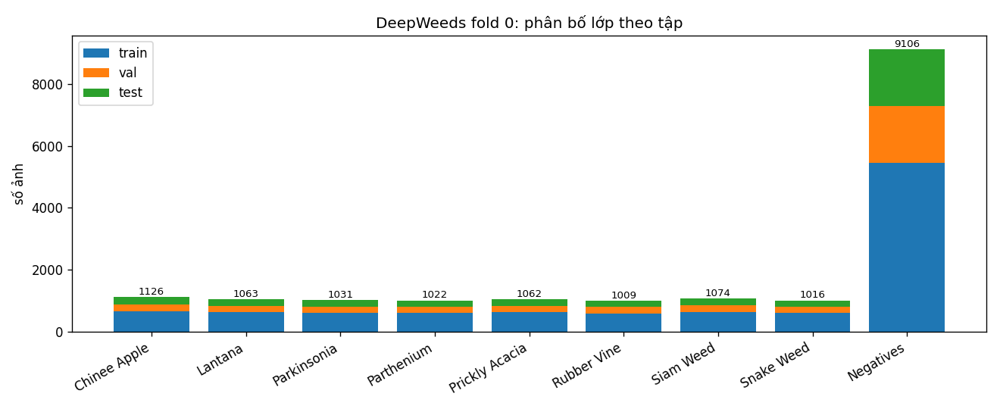

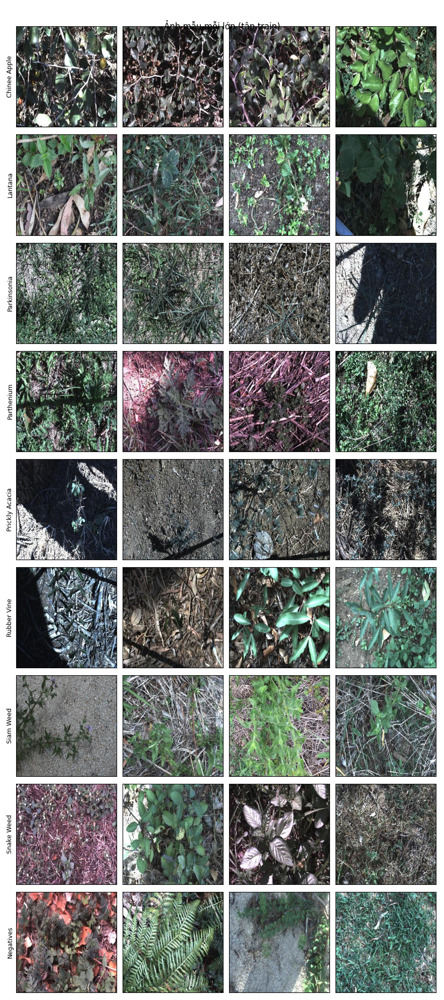

In [4]:
from pipeline_checks import eda_plots
FIGS = OUT / "figures"
eda = eda_plots(split_info, train_df, IMAGES_DIR, FIGS)
print(eda)

all_files = pd.concat([train_df, val_df, test_df])["Filename"].tolist()
t0 = time.time()
shapes = preload_images(all_files, IMAGES_DIR)   # giải mã một lần, giữ trong RAM cho mọi lần chạy
print(f"nạp {len(all_files)} ảnh vào RAM trong {time.time() - t0:.0f}s; kích thước (H, W, C):", shapes)
print("chế độ màu gốc (2000 ảnh đầu):", image_modes(all_files[:2000], IMAGES_DIR))
json.dump({"eda": eda, "shapes": shapes}, open(OUT / "eda.json", "w"), ensure_ascii=False, indent=2, default=str)
display(ShowImage(str(FIGS / "eda_class_distribution.png")))
display(ShowImage(str(FIGS / "eda_samples.png")))

### 0.3 Kiểm tra pipeline: seed, loss ban đầu, overfit một batch nhỏ, ảnh sau augmentation, train/eval mode

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

{
  "initial_loss": [
    {
      "backbone": "resnet50",
      "initial_loss": 2.186587691307068,
      "expected": 2.1972245773362196,
      "logit_std": 0.06515701301395893
    },
    {
      "backbone": "convnext_tiny",
      "initial_loss": 2.5219613313674927,
      "expected": 2.1972245773362196,
      "logit_std": 0.7750753164291382
    },
    {
      "backbone": "deit_small_patch16_224",
      "initial_loss": 2.276096820831299,
      "expected": 2.1972245773362196,
      "logit_std": 0.4239823967218399
    }
  ],
  "overfit": {
    "backbone": "resnet50",
    "n_images": 32,
    "steps": 100,
    "loss_first": 2.187690258026123,
    "loss_last": 0.0019833804108202457,
    "train_acc_eval_mode": 1.0
  },
  "modes": {
    "train_mode_ok": true,
    "eval_mode_ok": true,
    "frozen_bn_eval_ok": true
  }
}


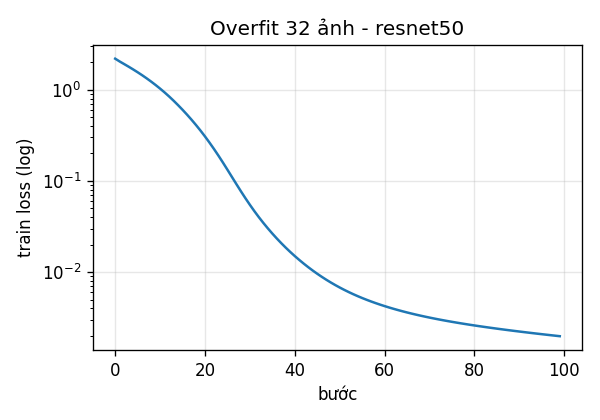

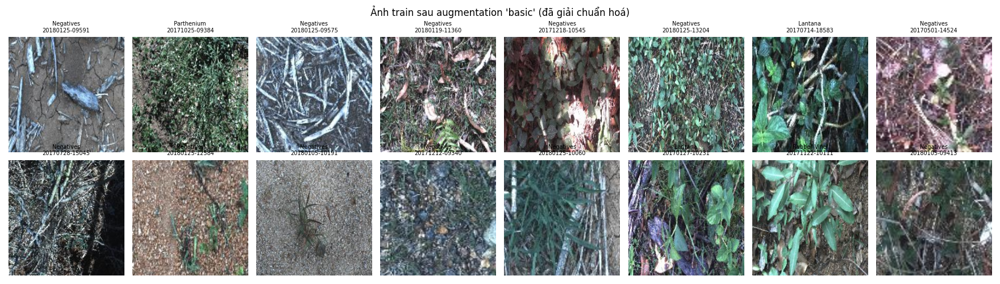

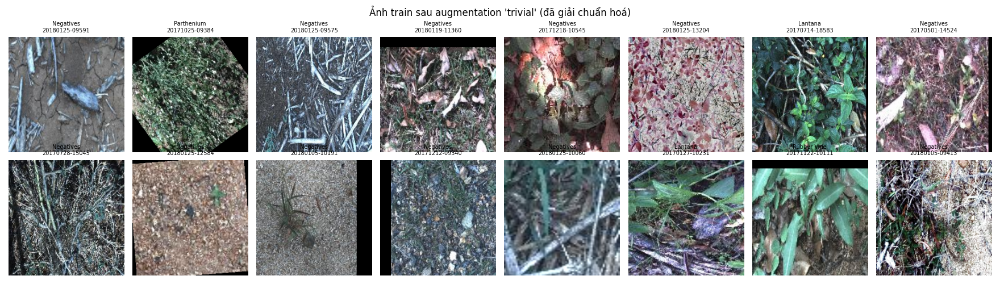

In [5]:
from train import set_seed
from pipeline_checks import initial_loss, overfit_small_batch, show_augmented, check_modes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(0)
checks = {}
checks["initial_loss"] = [initial_loss(b, val_df, IMAGES_DIR, device)
                          for b in ("resnet50", "convnext_tiny", "deit_small_patch16_224")]
checks["overfit"] = overfit_small_batch("resnet50", train_df, IMAGES_DIR, device, n=32,
                                        steps=40 if SMOKE else 100, fig_path=FIGS / "check_overfit_32.png")
show_augmented(train_df, IMAGES_DIR, FIGS / "check_aug_basic.png", "basic")
show_augmented(train_df, IMAGES_DIR, FIGS / "check_aug_trivial.png", "trivial")
checks["modes"] = check_modes(device)
json.dump(checks, open(OUT / "pipeline_checks.json", "w"), ensure_ascii=False, indent=2)
print(json.dumps(checks, indent=2, ensure_ascii=False))
for f in ("check_overfit_32.png", "check_aug_basic.png", "check_aug_trivial.png"):
    display(ShowImage(str(FIGS / f)))

### 0.4 Test tự viết (focal γ=0, CutMix, gộp BN, ...) và test của repo

In [6]:
r = subprocess.run([sys.executable, "-m", "unittest", "test_own", "-v"], cwd=CODE_DIR, capture_output=True, text=True)
print(r.stderr[-6000:])
(OUT / "test_own.txt").write_text(r.stderr)
assert r.returncode == 0, "test tự viết lỗi"
repo = CODE_DIR.parent
if (repo / "tests").exists():
    r = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests"], cwd=repo, capture_output=True, text=True)
    print(r.stderr[-3000:])
    (OUT / "test_repo.txt").write_text(r.stderr)

test_parse_overrides (test_own.TestCLI.test_parse_overrides) ... ok
test_aggregate (test_own.TestInference.test_aggregate) ... ok
test_fuse_bn (test_own.TestInference.test_fuse_bn) ... ok
test_fuse_bn_act_efficientnet (test_own.TestInference.test_fuse_bn_act_efficientnet) ... ok
test_temperature_recovers_T (test_own.TestInference.test_temperature_recovers_T) ... ok
test_views (test_own.TestInference.test_views) ... ok
test_class_weights (test_own.TestLosses.test_class_weights) ... ok
test_cutmix_mixes_images_and_labels (test_own.TestLosses.test_cutmix_mixes_images_and_labels) ... ok
test_focal_downweights_easy (test_own.TestLosses.test_focal_downweights_easy) ... ok
test_focal_gamma0_equals_ce (test_own.TestLosses.test_focal_gamma0_equals_ce) ... ok
test_ls_eps0_equals_ce_and_matches_torch (test_own.TestLosses.test_ls_eps0_equals_ce_and_matches_torch) ... ok
test_mixup_and_mixed_loss (test_own.TestLosses.test_mixup_and_mixed_loss) ... ok
test_counts (test_own.TestModel.test_counts) ...

........LỖI: /tmp/tmpmq2zyg8l/F01_seed0_test.csv: không khớp test CSV (/tmp/tmpmq2zyg8l/short.csv): thừa 590 ảnh, thiếu 0 ảnh
..............................
----------------------------------------------------------------------
Ran 38 tests in 0.967s

OK



## Bước 1 — So sánh backbone (5 backbone, công thức nền T00, seed 0)
ResNet-50 (mốc), ConvNeXt-T, DeiT-S, EfficientNet-B0, MobileNetV3-L. Cùng công thức: AdamW, LR backbone 1e-4 / head 1e-3,
wd 0,05 (không áp cho norm/bias), warmup + cosine theo bước, AMP, CE, chọn checkpoint theo macro-F1 val.

**Giảm do ngân sách GPU** (cả notebook phải chạy trong khoảng 30 phút trên một T4): ảnh train 128×128
(RandomResizedCrop 128), 4 epoch, batch 128, warmup 0,5 epoch. Val/test: resize 146 rồi center crop 128.
DeiT-S dùng trọng số 224 được timm nội suy pos-embed về 128. Mọi backbone vẫn cùng một công thức.

[B01 seed0] đã có kết quả, bỏ qua huấn luyện
[B02 seed0] đã có kết quả, bỏ qua huấn luyện
[B03 seed0] đã có kết quả, bỏ qua huấn luyện
[B04 seed0] đã có kết quả, bỏ qua huấn luyện
[B05 seed0] đã có kết quả, bỏ qua huấn luyện


,exp_id,backbone,weight_tag,params_m,gmacs,best_epoch,val_macro_f1,val_top1,sec_per_epoch
0,B01,resnet50,resnet50.a1_in1k,23.526473,1.341884,4,0.522624,0.677806,13.401789
1,B02,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.827049,1.459493,4,0.941212,0.955441,23.612363
2,B03,deit_small_patch16_224,deit_small_patch16_224.fb_in1k,21.618441,1.402186,4,0.893381,0.921165,11.753737
3,B04,efficientnet_b0,efficientnet_b0.ra_in1k,4.019077,0.130417,4,0.585094,0.689517,20.375060
4,B05,mobilenetv3_large_100,mobilenetv3_large_100.ra_in1k,4.213561,0.075048,4,0.565567,0.681520,15.384272


Chọn đi tiếp: {'exp_id': 'B02', 'backbone': 'convnext_tiny', 'reason': 'macro-F1 val cao nhất (0.9412) trong 5 backbone, 1 seed'}


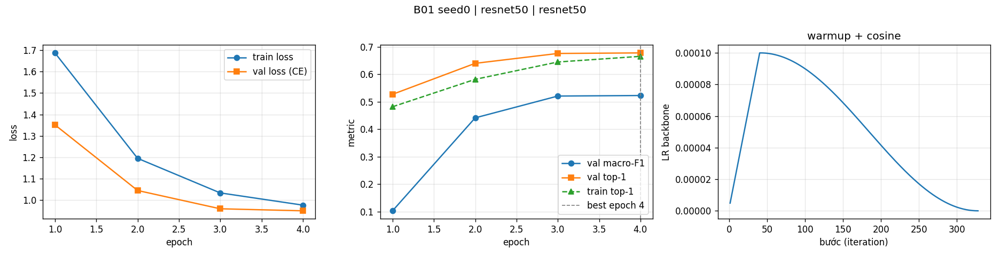

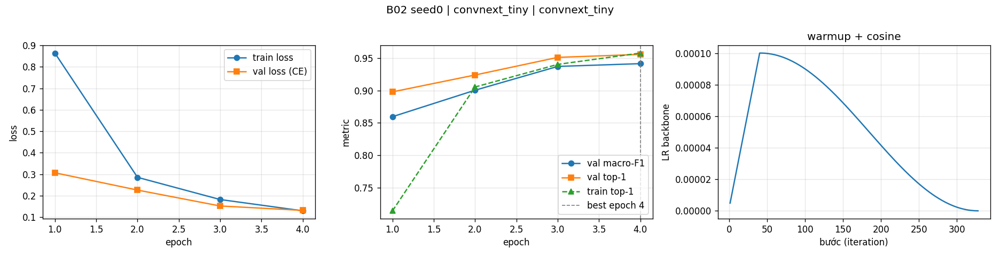

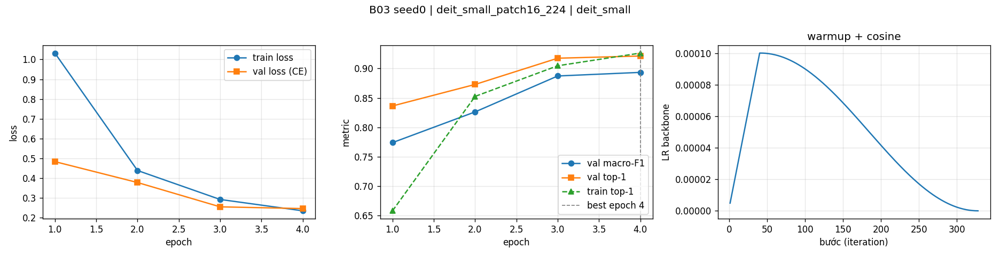

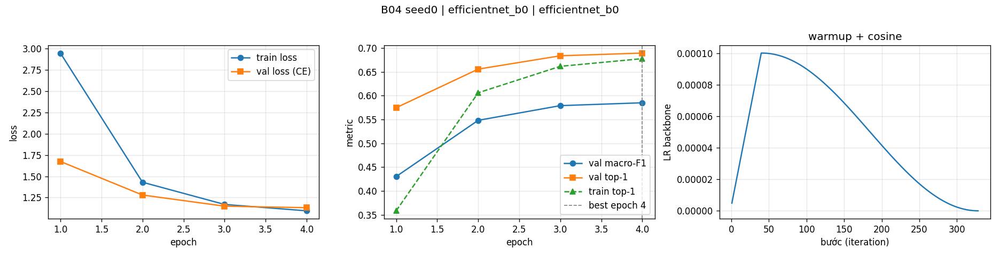

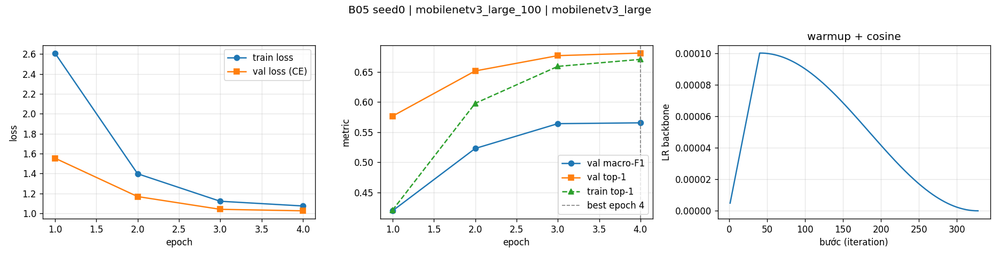

In [7]:
from experiments import Lab, step1, step2, step3, step4, run_eval, confusion_and_errors, BACKBONES
lab = Lab(images_dir=IMAGES_DIR, labels_dir=LABELS_DIR, out=str(OUT), ckpt_dir=CKPT, num_workers=4, smoke=SMOKE)
df1 = step1(lab)
display(df1[["exp_id", "backbone", "weight_tag", "params_m", "gmacs", "best_epoch", "val_macro_f1", "val_top1",
             "sec_per_epoch"]])
dec = lab.load_json("decisions.json")
print("Chọn đi tiếp:", dec["step1_backbone"])
for e, _, d in BACKBONES:
    display(ShowImage(str(OUT / "curves" / f"{e}_{d}.png")))

## Bước 2 — Công thức huấn luyện (backbone đã chọn ở Bước 1)
T00 chạy 3 seed để đo nhiễu (seed 0 chính là lần chạy B0x của backbone này, chép lại, không train lại).
Mỗi T01–T06 chỉ khác T00 một yếu tố (trục A, B, C, F). T07 là kết hợp các yếu tố tốt
(tham lam theo trục: chỉ lấy yếu tố có Δ > std nhiễu; xem `decisions.json`).

[T00 seed1] convnext_tiny (convnext_tiny.in12k_ft_in1k) 27.8M, 1.46 GMAC, 10501 ảnh train, 82 bước/epoch, mean=(0.485, 0.456, 0.406)


/kaggle/working/repo/code/train.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  ep  1 | loss 0.9208 | val loss 0.3617 | val F1 0.8131 | val top1 0.8672 | 42s


  ep  2 | loss 0.3111 | val loss 0.2751 | val F1 0.8899 | val top1 0.9143 | 19s


  ep  3 | loss 0.1845 | val loss 0.1331 | val F1 0.9400 | val top1 0.9543 | 18s


...

  ep  3 | loss 0.7018 | val loss 0.2391 | val F1 0.9453 | val top1 0.9574 | 19s


  ep  4 | loss 0.6510 | val loss 0.2138 | val F1 0.9452 | val top1 0.9569 | 19s


[T07 seed0] xong: best epoch 3, val macro-F1 0.9453, val top-1 0.9574, 19s/epoch


,exp_id,seed,axis,change,best_epoch,val_macro_f1,val_top1,delta_vs_T00,noise_std,distinguishable
0,T00,0,-,công thức nền T00,4,0.941212,0.955441,0.000000,0.003721,False
1,T00,1,-,công thức nền T00,4,0.948646,0.960297,0.007433,0.003721,True
2,T00,2,-,công thức nền T00,4,0.944636,0.957155,0.003424,0.003721,False
3,T01,0,A,init=frozen (chỉ train head),4,0.747622,0.806627,-0.193590,0.003721,True
4,T02,0,B,aug=trivial (+TrivialAugmentWide),3,0.948394,0.959155,0.007182,0.003721,True
5,T03,0,B,mix=cutmix (alpha=1),4,0.944281,0.957155,0.003069,0.003721,False
6,T04,0,C,loss=label smoothing eps=0.1,4,0.945876,0.958012,0.004664,0.003721,True
7,T05,0,C,loss=CE trọng số 1/n_c,4,0.932674,0.945159,-0.008538,0.003721,True
8,T06,0,F,EMA decay=0.99,3,0.943251,0.956013,0.002039,0.003721,False
9,T07,0,kết hợp,kết hợp T02 + T04,3,0.945316,0.957441,0.004103,0.003721,True


{
  "step2_noise_std": 0.0037205331719145345,
  "step2_combination": {
    "members": [
      "T02",
      "T04"
    ],
    "cfg": {
      "aug": "trivial",
      "loss": "ls",
      "label_smoothing": 0.1
    },
    "note": "các yếu tố đều có Δ > std nhiễu"
  },
  "step2_recipe": {
    "exp_id": "T02",
    "cfg": {
      "aug": "trivial"
    },
    "backbone": "convnext_tiny",
    "val_macro_f1": 0.948393773619887,
    "delta_vs_T00": 0.007181627455327688,
    "reason": "macro-F1 val cao nhất (0.9484) trong các cấu hình seed 0; Δ so với T00 = +0.0072, std nhiễu T00 = 0.0037 (vượt nhiễu)"
  }
}


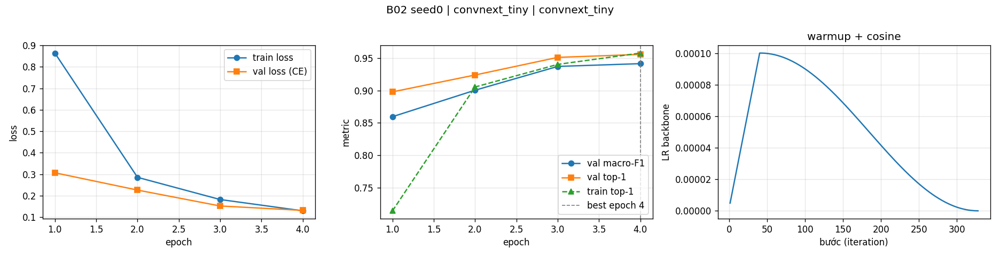

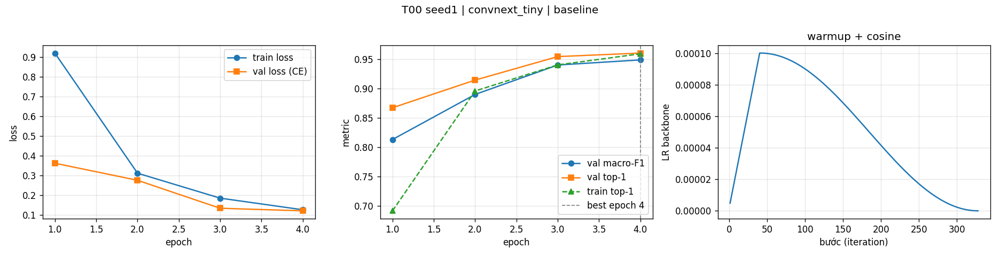

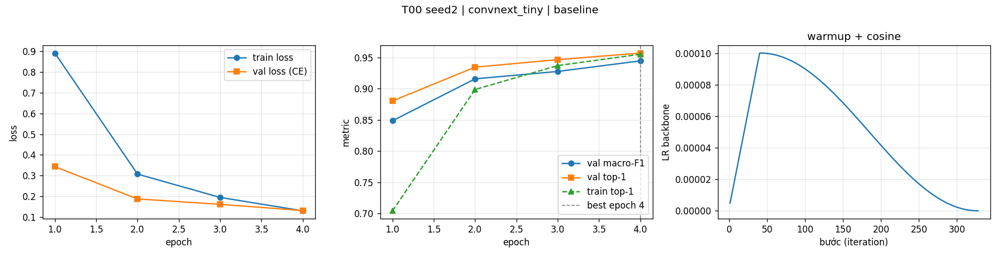

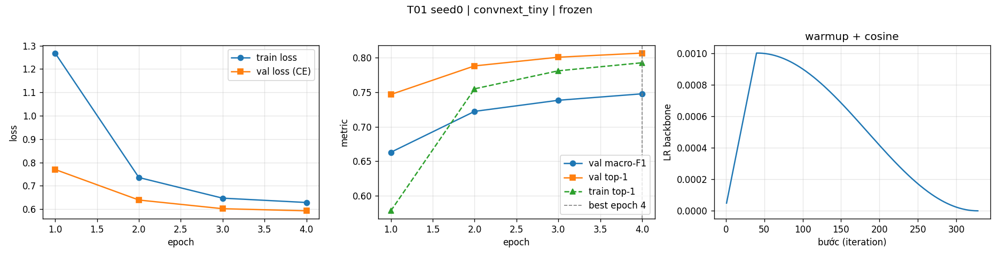

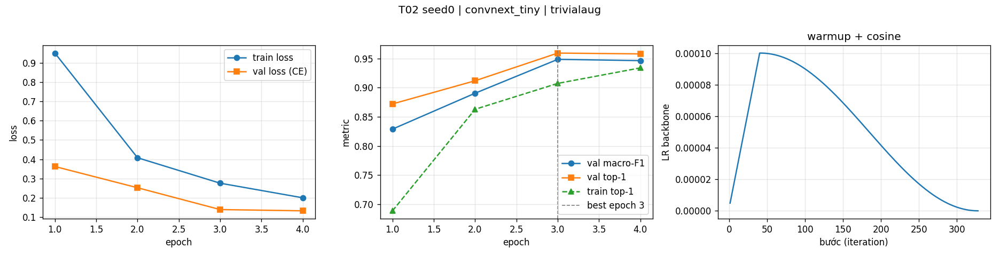

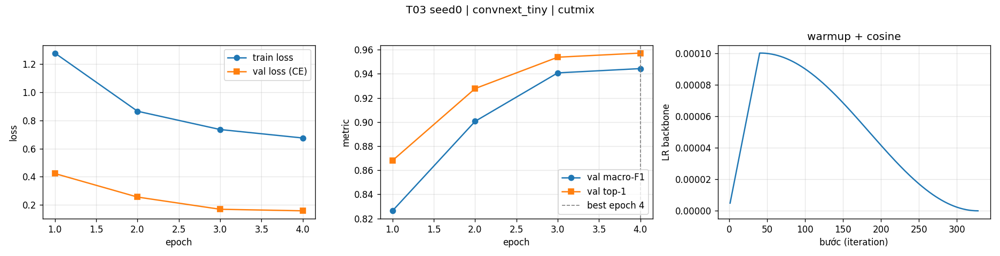

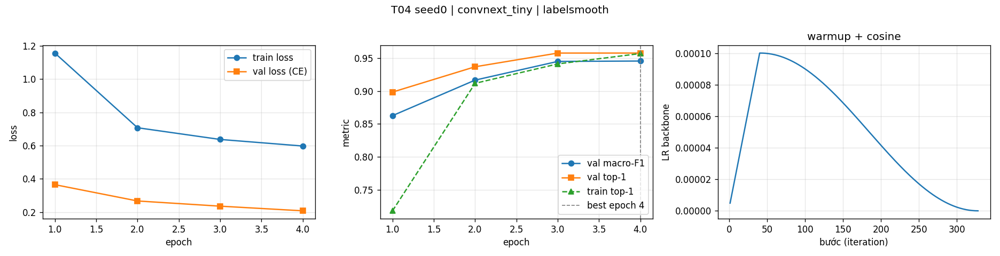

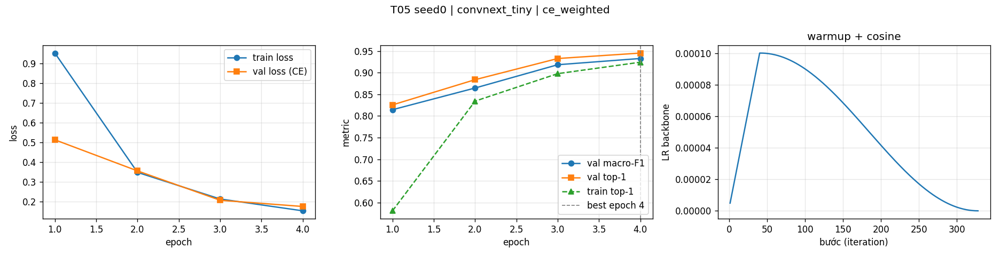

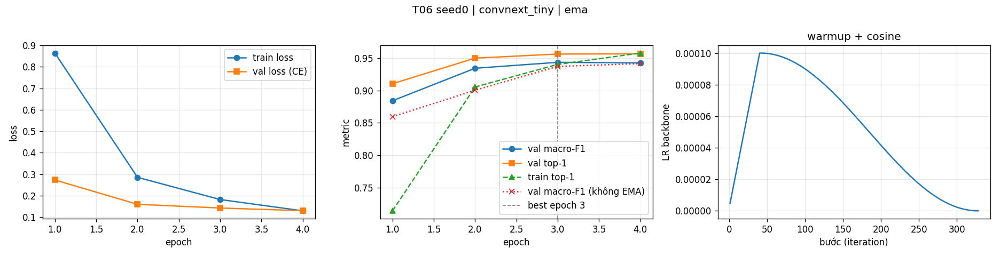

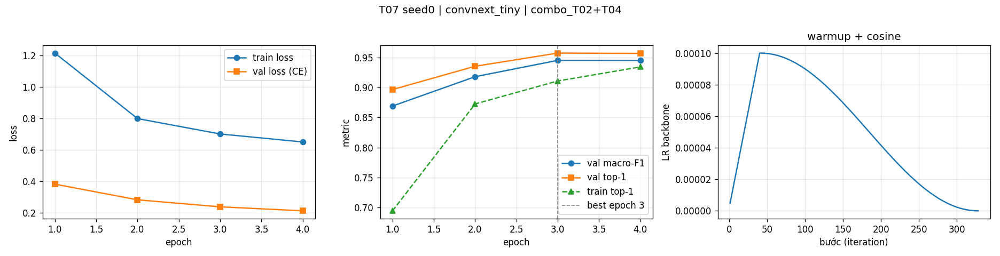

In [8]:
df2 = step2(lab, dec["step1_backbone"]["backbone"])
dec = lab.load_json("decisions.json")
display(df2[["exp_id", "seed", "axis", "change", "best_epoch", "val_macro_f1", "val_top1", "delta_vs_T00",
             "noise_std", "distinguishable"]])
print(json.dumps({k: dec[k] for k in ("step2_noise_std", "step2_combination", "step2_recipe")}, indent=2, ensure_ascii=False))
for p in sorted((OUT / "curves").glob("T*.png")):
    display(ShowImage(str(p)))

## Bước 3 — Suy luận và độ trễ (không train lại)
Mô hình: cấu hình tốt nhất của Bước 2 (seed 0). Mọi số trên **val**. Độ trễ: warmup 10 lần, `torch.cuda.synchronize()`
trước và sau, 60 lần đo, p50/p95/p99, batch 1 và batch 32; mặc định không tính tiền xử lý (có một dòng tính cả tiền xử lý).

,exp_id,method,model,K,val_macro_f1,val_top1,val_ece,val_nll,f1_chinee,f1_snake,ece_before,ece_after_crossfit,T,note,lat_b1_p50_ms,lat_b1_p95_ms,lat_b1_p99_ms,throughput_b32_img_s,rel_cost_vs_I00
0,I00,1 view (resize 146 + center crop 128),T02 seed0 (convnext_tiny),1,0.948097,0.958869,0.012482,0.139768,0.921700,0.883495,NaN,NaN,NaN,NaN,5.899364,6.385035,6.738348,635.793526,1.000000
1,I01,"TTA lật ngang, gộp xác suất",T02 seed0 (convnext_tiny),2,0.945964,0.958298,0.014311,0.135552,0.910314,0.874396,NaN,NaN,NaN,NaN,11.067269,12.243230,12.583438,298.187322,1.876011
2,I01L,"TTA lật ngang, gộp logit",T02 seed0 (convnext_tiny),2,0.945964,0.958298,0.013186,0.134529,0.910314,0.874396,NaN,NaN,NaN,NaN,11.067269,12.243230,12.583438,298.187322,1.876011
3,I02,"TTA 5 crop 128 từ ảnh 146, gộp xác suất",T02 seed0 (convnext_tiny),5,0.950850,0.961440,0.019486,0.129163,0.920354,0.886199,NaN,NaN,NaN,NaN,27.464750,28.572942,29.462359,126.297068,4.655545
4,I02L,"TTA 5 crop 128 từ ảnh 146, gộp logit",T02 seed0 (convnext_tiny),5,0.950901,0.961440,0.013156,0.125602,0.920354,0.884058,NaN,NaN,NaN,NaN,27.464750,28.572942,29.462359,126.297068,4.655545
5,I02F,"TTA 10 crop (5 crop + lật), gộp xác suất",T02 seed0 (convnext_tiny),10,0.952667,0.963439,0.023598,0.126502,0.920705,0.894866,NaN,NaN,NaN,NaN,55.560959,59.377681,60.615460,63.068805,9.418128
6,I04_R160,độ phân giải kiểm tra 160 (resize 183 + crop 160),T02 seed0 (convnext_tiny),1,0.954505,0.964010,0.011958,0.115728,0.917431,0.893204,NaN,NaN,NaN,NaN,5.580917,5.951188,6.625926,409.759031,0.946020
7,I04_R192,độ phân giải kiểm tra 192 (resize 219 + crop 192),T02 seed0 (convnext_tiny),1,0.949369,0.958869,0.013236,0.130164,0.915888,0.909091,NaN,NaN,NaN,NaN,5.611781,5.943057,6.145822,280.028960,0.951252
8,I04_R224,độ phân giải kiểm tra 224 (resize 256 + crop 224),T02 seed0 (convnext_tiny),1,0.935078,0.946301,0.010134,0.166752,0.884706,0.878947,NaN,NaN,NaN,NaN,5.818297,6.066108,6.866851,205.714054,0.986258
9,I05a,ensemble 3 backbone tốt nhất Bước 1 (TB xác suất),B02:convnext_tiny + B03:deit_small_patch16_224 + B04:eff...,3,0.924033,0.942588,0.102526,0.267530,0.849188,0.862338,NaN,NaN,NaN,NaN,18.449433,19.701975,20.222955,306.433671,3.127360


,config,dtype,batch,img_size,fused_bn,preprocess,p50,p95,p99,images_per_s
0,T02 (convnext_tiny) I00 fp32,fp32,1,128.0,False,False,5.899364,6.385035,6.738348,169.509812
1,T02 (convnext_tiny) I00 amp,amp,1,128.0,False,False,7.713581,8.044728,8.799775,129.641473
2,T02 (convnext_tiny) I00 fp16,fp16,1,128.0,False,False,5.420817,5.855121,6.176196,184.474021
3,B01 seed0 (resnet50) gộp BN fp32,fp32,1,128.0,True,False,4.486069,4.690224,4.896394,222.912284
4,B01 seed0 (resnet50) chưa gộp BN fp32,fp32,1,128.0,False,False,5.839915,6.375107,6.650725,171.235354
5,T02 (convnext_tiny) I01 K=2 tuần tự,fp32,1,128.0,False,False,11.067269,12.243230,12.583438,90.356524
6,T02 (convnext_tiny) I01 K=2 gộp batch,fp32,1,128.0,False,False,5.848072,8.756907,10.426727,170.996527
7,T02 (convnext_tiny) I02 K=5 tuần tự,fp32,1,128.0,False,False,27.464750,28.572942,29.462359,36.410308
8,T02 (convnext_tiny) I02 K=5 gộp batch,fp32,1,128.0,False,False,7.989926,8.680652,8.898442,125.157605
9,T02 (convnext_tiny) I02F K=10 tuần tự,fp32,1,128.0,False,False,55.560959,59.377681,60.615460,17.998249


{
  "method": "R160",
  "desc": "độ phân giải kiểm tra 160 (resize 183 + crop 160)",
  "val_macro_f1": 0.9545048386497371,
  "delta_vs_I00": 0.006408210017816662,
  "p95_b1_ms": 5.951188249844108,
  "temperature_scaling": true,
  "reason": "macro-F1 val cao nhất trong các cách suy luận một mô hình; Δ so với I00 = +0.0064 (std nhiễu seed 0.0037); p95 batch 1 = 6.0 ms. Sau đó áp temperature scaling khớp trên val."
}


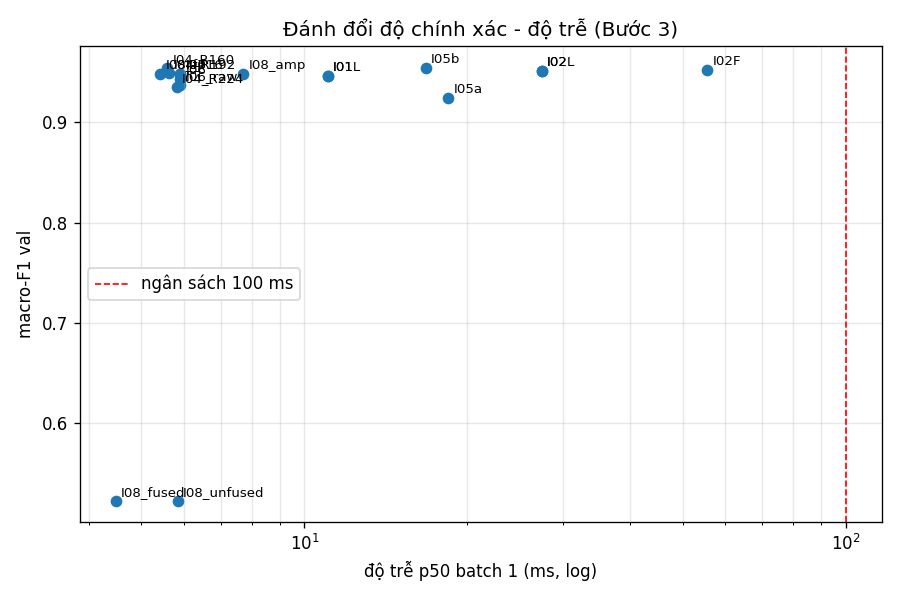

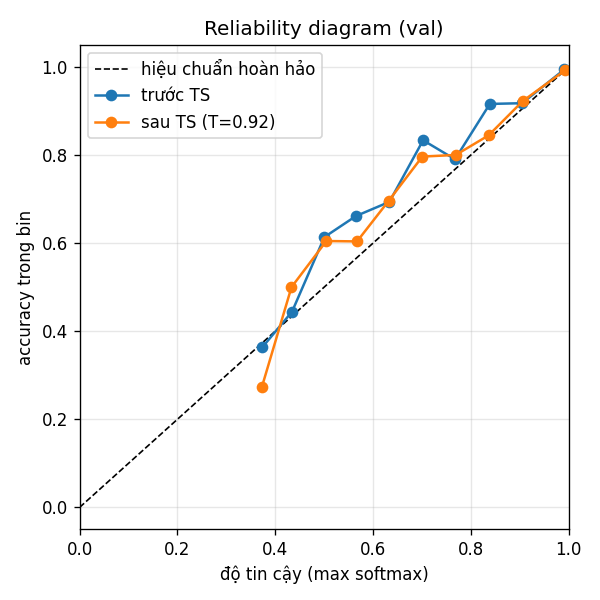

In [9]:
res3 = step3(lab)
dec = lab.load_json("decisions.json")
pd.set_option("display.max_colwidth", 60)
display(res3["inference"])
display(res3["latency"][["config", "dtype", "batch", "img_size", "fused_bn", "preprocess", "p50", "p95", "p99", "images_per_s"]])
print(json.dumps(dec["step3_method"], indent=2, ensure_ascii=False))
display(ShowImage(str(OUT / "figures" / "accuracy_latency_tradeoff.png")))
display(ShowImage(str(OUT / "figures" / "reliability_val.png")))

## Bước 4 — Chung kết: 3 seed, test một lần mỗi seed
F01 = backbone + công thức + cách suy luận đã chốt trên val, rồi temperature scaling (T khớp trên val của từng seed).
Mốc = T00 + I00, dùng lại checkpoint T00 seed 0/1/2 đã train ở Bước 2 (chọn trên val), chạy test một lần.

[F01 seed0] convnext_tiny (convnext_tiny.in12k_ft_in1k) 27.8M, 1.46 GMAC, 10501 ảnh train, 82 bước/epoch, mean=(0.485, 0.456, 0.406)


/kaggle/working/repo/code/train.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  ep  1 | loss 0.9497 | val loss 0.3626 | val F1 0.8289 | val top1 0.8720 | 19s


  ep  2 | loss 0.4080 | val loss 0.2527 | val F1 0.8904 | val top1 0.9117 | 19s


  ep  3 | loss 0.2762 | val loss 0.1397 | val F1 0.9484 | val top1 0.9592 | 19s


...

p95 batch 1 của cấu hình chung kết: 5.951188249844108 ms


### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9628 ± 0.0022 |
| macro-F1 | 0.9539 ± 0.0040 |
| balanced accuracy | 0.9431 ± 0.0081 |
| ECE (15 bin) | 0.0053 ± 0.0003 |
| NLL | 0.1184 ± 0.0076 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.955 ± 0.005 | 0.879 ± 0.014 | 0.915 ± 0.008 | 226 |
| Lantana | 0.976 ± 0.014 | 0.939 ± 0.014 | 0.957 ± 0.007 | 213 |
| Parkinsonia | 0.968 ± 0.007 | 0.982 ± 0.003 | 0.975 ± 0.003 | 207 |
| Parthenium | 0.984 ± 0.005 | 0.927 ± 0.013 | 0.955 ± 0.009 | 205 |
| Prickly acacia | 0.960 ± 0.007 | 0.928 ± 0.007 | 0.944 ± 0.007 | 213 |
| Rubber vine | 0.972 ± 0.018 | 0.970 ± 0.010 | 0.971 ± 0.005 | 202 |
| Siam weed | 0.980 ± 0.007 | 0.963 ± 0.005 | 0.971 ± 0.006 | 215 |
| Snake weed | 0.936 ± 0.023 | 0.913 ± 0.028 | 0.924 ± 0.009 | 204 |
| Negative | 0.960 ± 0.008 | 0.987 ± 0.006 | 0.973 ± 0.002 | 1822 |

Đã lưu kết quả vào /kaggle/working/out/eval_out/F01_*
 


### T00 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9628 ± 0.0031 |
| macro-F1 | 0.9520 ± 0.0051 |
| balanced accuracy | 0.9471 ± 0.0062 |
| ECE (15 bin) | 0.0068 ± 0.0004 |
| NLL | 0.1148 ± 0.0077 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.927 ± 0.013 | 0.900 ± 0.028 | 0.913 ± 0.019 | 226 |
| Lantana | 0.973 ± 0.002 | 0.947 ± 0.014 | 0.960 ± 0.007 | 213 |
| Parkinsonia | 0.962 ± 0.009 | 0.981 ± 0.005 | 0.971 ± 0.007 | 207 |
| Parthenium | 0.991 ± 0.008 | 0.935 ± 0.003 | 0.962 ± 0.002 | 205 |
| Prickly acacia | 0.919 ± 0.010 | 0.961 ± 0.007 | 0.940 ± 0.002 | 213 |
| Rubber vine | 0.972 ± 0.012 | 0.962 ± 0.003 | 0.967 ± 0.005 | 202 |
| Siam weed | 0.975 ± 0.018 | 0.953 ± 0.008 | 0.964 ± 0.008 | 215 |
| Snake weed | 0.929 ± 0.007 | 0.904 ± 0.031 | 0.916 ± 0.019 | 204 |
| Negative | 0.970 ± 0.003 | 0.982 ± 0.005 | 0.976 ± 0.001 | 1822 |

Đã lưu kết quả vào /kaggle/working/out/eval_out/T00_*
 


### F01_uncal (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9628 ± 0.0022 |
| macro-F1 | 0.9539 ± 0.0040 |
| balanced accuracy | 0.9431 ± 0.0081 |
| ECE (15 bin) | 0.0069 ± 0.0022 |
| NLL | 0.1187 ± 0.0077 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.955 ± 0.005 | 0.879 ± 0.014 | 0.915 ± 0.008 | 226 |
| Lantana | 0.976 ± 0.014 | 0.939 ± 0.014 | 0.957 ± 0.007 | 213 |
| Parkinsonia | 0.968 ± 0.007 | 0.982 ± 0.003 | 0.975 ± 0.003 | 207 |
| Parthenium | 0.984 ± 0.005 | 0.927 ± 0.013 | 0.955 ± 0.009 | 205 |
| Prickly acacia | 0.960 ± 0.007 | 0.928 ± 0.007 | 0.944 ± 0.007 | 213 |
| Rubber vine | 0.972 ± 0.018 | 0.970 ± 0.010 | 0.971 ± 0.005 | 202 |
| Siam weed | 0.980 ± 0.007 | 0.963 ± 0.005 | 0.971 ± 0.006 | 215 |
| Snake weed | 0.936 ± 0.023 | 0.913 ± 0.028 | 0.924 ± 0.009 | 204 |
| Negative | 0.960 ± 0.008 | 0.987 ± 0.006 | 0.973 ± 0.002 | 1822 |

Đã lưu kết quả vào /kaggle/working/out/eval_out/F01_uncal_*
 

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 96.28% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 2 | 5 | final 0.9539, mốc 0.9520, Δ=+0.0019, s=0.0051 |
| I3 | Recall hai lớp khó | 3 | 4 | Chinee Apple 87.9% (mốc 88.5%), Snake Weed 91.3% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0069, sau 0.0053 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9510, test 0.9539, chênh 0.0029 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 6.0 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 16 / 20** (phần I tối đa 20).

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).
 


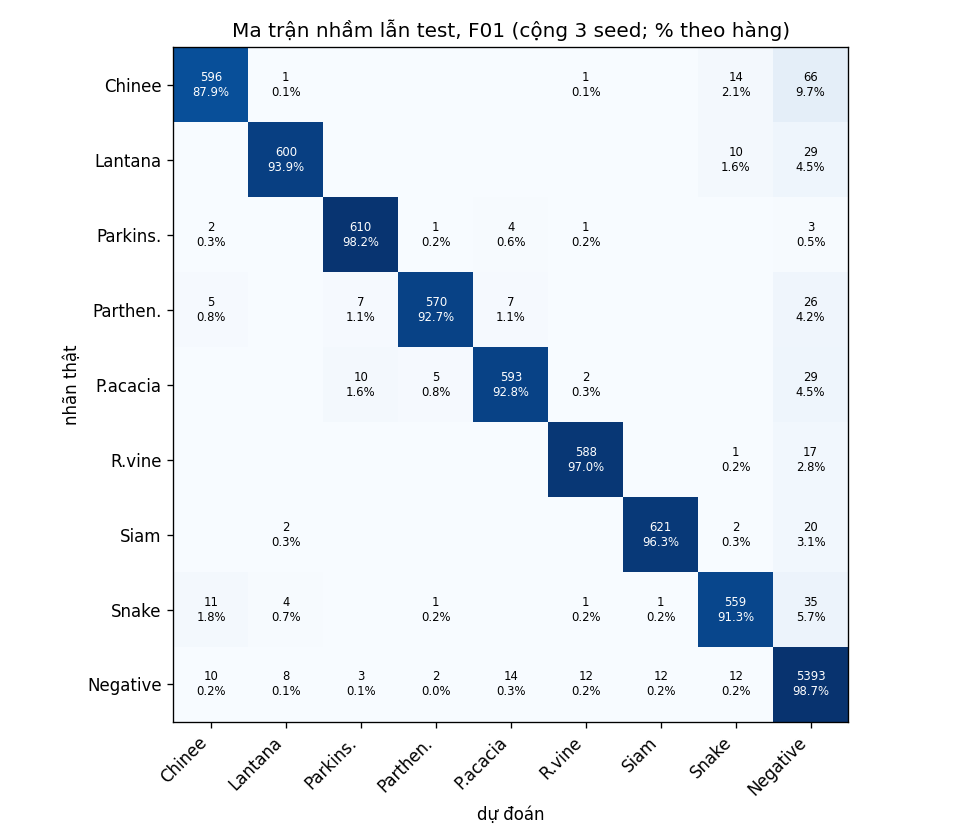

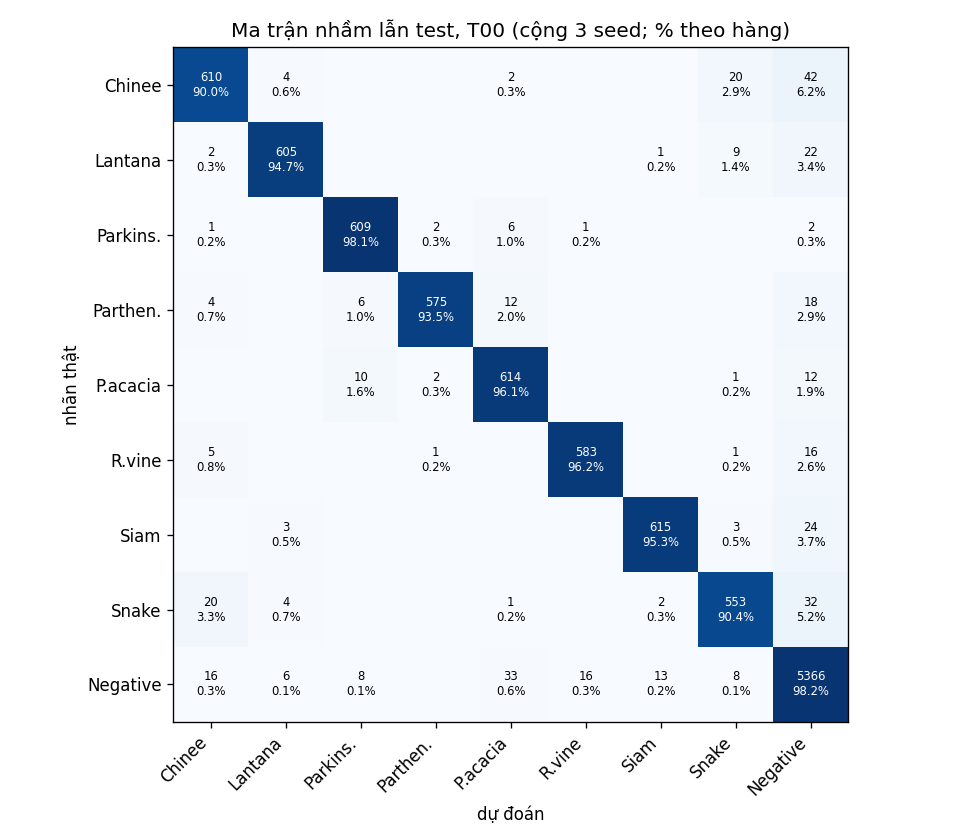

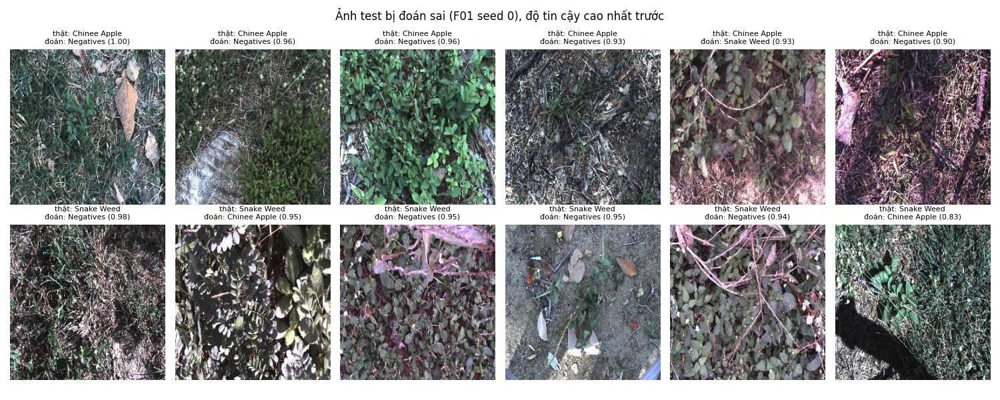

In [10]:
res4 = step4(lab)
display(res4["final_val"])
inf_df = res3["inference"].set_index("exp_id")
p95 = float(inf_df.loc[dec["step3_method"]["method"] if dec["step3_method"]["method"] in inf_df.index
                       else "I04_" + dec["step3_method"]["method"], "lat_b1_p95_ms"])
print("p95 batch 1 của cấu hình chung kết:", p95, "ms")
logs = run_eval(lab, latency_p95_ms=p95)
confusion_and_errors(lab)
for f in ("confusion_test_F01.png", "confusion_test_T00.png", "errors_hard_classes.png"):
    if (OUT / "figures" / f).exists():
        display(ShowImage(str(OUT / "figures" / f)))

## Phần làm thêm
1. Lệch phân phối tự tạo trên **val** (mờ, tối, nhiễu, JPEG nén mạnh): macro-F1 và ECE trước/sau temperature scaling
   (T khớp trên val sạch). Không dùng test.
2. Grad-CAM trên các ảnh test đã bị đoán sai của Chinee apple / Snake weed (chỉ để giải thích lỗi, không quyết định gì).

,lệch phân phối (val),macro-F1 val,top-1 val,recall Chinee apple,recall Snake weed,ECE trước TS,ECE sau TS (T từ val sạch),T
0,sạch,0.948097,0.958869,0.915556,0.896552,0.012482,0.007129,0.915002
1,mờ (Gaussian r=2.5),0.443312,0.639246,0.280000,0.118227,0.143544,0.165236,0.915002
2,tối (độ sáng x0.4),0.908494,0.924022,0.911111,0.871921,0.015125,0.010106,0.915002
3,nhiễu Gaussian std=0.08,0.798880,0.838903,0.640000,0.738916,0.049830,0.061108,0.915002
4,JPEG quality 10,0.390503,0.619823,0.275556,0.108374,0.158207,0.180312,0.915002


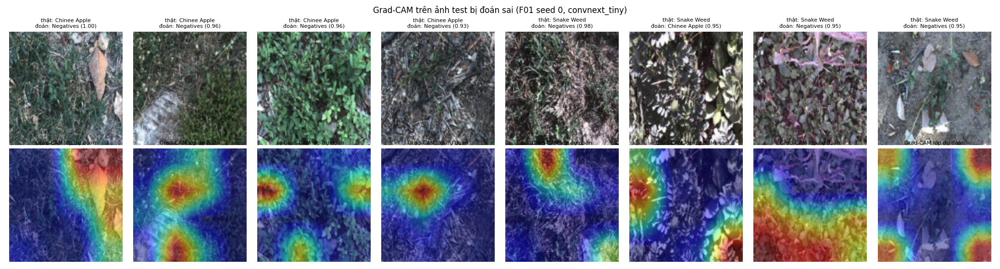

In [11]:
from bonus import shift_eval, gradcam_errors
display(shift_eval(lab))
g = gradcam_errors(lab)
if g:
    display(ShowImage(str(g)))

## Bước 5 — results.xlsx, biểu đồ tổng hợp, bảng cho báo cáo

đã ghi /kaggle/working/out/results.xlsx
===== Backbones (5, 18)


,exp_id,backbone,tag trọng số,#tham số (M),GMAC,độ phân giải,epoch,seed,best epoch,macro-F1 val,top-1 val,F1 Chinee apple val,F1 Snake weed val,thời gian train/epoch (s),độ trễ batch-1 p50 (ms),độ trễ batch-1 p95 (ms),thông lượng batch-32 (ảnh/s),ghi chú
0,B01,resnet50,resnet50.a1_in1k,23.526473,1.341884,128,4,0,4,0.522624,0.677806,0.390805,0.424242,13.401789,6.110627,6.601710,828.698460,"công thức nền T00, 1 seed; độ trễ FP32 đo ở Bước 3 (warm..."
1,B02,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.827049,1.459493,128,4,0,4,0.941212,0.955441,0.870748,0.890547,23.612363,5.716306,6.058725,625.417209,"công thức nền T00, 1 seed; độ trễ FP32 đo ở Bước 3 (warm..."
2,B03,deit_small_patch16_224,deit_small_patch16_224.fb_in1k,21.618441,1.402186,128,4,0,4,0.893381,0.921165,0.801843,0.816537,11.753737,4.768379,5.222988,771.645631,"công thức nền T00, 1 seed; độ trễ FP32 đo ở Bước 3 (warm..."
3,B04,efficientnet_b0,efficientnet_b0.ra_in1k,4.019077,0.130417,128,4,0,4,0.585094,0.689517,0.453704,0.439024,20.375060,7.907528,11.097349,2535.440607,"công thức nền T00, 1 seed; độ trễ FP32 đo ở Bước 3 (warm..."
4,B05,mobilenetv3_large_100,mobilenetv3_large_100.ra_in1k,4.213561,0.075048,128,4,0,4,0.565567,0.681520,0.436451,0.402145,15.384272,6.265934,6.595899,4554.297581,"công thức nền T00, 1 seed; độ trễ FP32 đo ở Bước 3 (warm..."


===== Training (10, 16)


,exp_id,backbone,trục (A–G),khác T00 ở điểm nào,seed,best epoch,macro-F1 val,top-1 val,Δ macro-F1 so với T00,std nhiễu T00 (3 seed),F1 Chinee apple val,F1 Snake weed val,F1 lớp thấp nhất val,F1 Negatives val,thời gian train/epoch (s),ghi chú
0,T00,convnext_tiny,-,công thức nền T00,0,4,0.941212,0.955441,0.000000,0.003721,0.870748,0.890547,0.870748,0.972313,23.612363,công thức nền; std qua 3 seed = 0.0037
1,T00,convnext_tiny,-,công thức nền T00,1,4,0.948646,0.960297,0.007433,0.003721,0.909502,0.902743,0.902743,0.973870,24.420403,công thức nền; std qua 3 seed = 0.0037
2,T00,convnext_tiny,-,công thức nền T00,2,4,0.944636,0.957155,0.003424,0.003721,0.887872,0.902256,0.887872,0.971770,18.633165,công thức nền; std qua 3 seed = 0.0037
3,T01,convnext_tiny,A,init=frozen (chỉ train head),0,4,0.747622,0.806627,-0.193590,0.003721,0.666667,0.657143,0.657143,0.862315,7.325552,Δ vượt std nhiễu
4,T02,convnext_tiny,B,aug=trivial (+TrivialAugmentWide),0,3,0.948394,0.959155,0.007182,0.003721,0.924107,0.883495,0.883495,0.972215,18.842438,Δ vượt std nhiễu
5,T03,convnext_tiny,B,mix=cutmix (alpha=1),0,4,0.944281,0.957155,0.003069,0.003721,0.882883,0.893939,0.882883,0.972517,18.870176,không phân biệt được với T00 (|Δ| ≤ std)
6,T04,convnext_tiny,C,loss=label smoothing eps=0.1,0,4,0.945876,0.958012,0.004664,0.003721,0.886836,0.895000,0.886836,0.972109,18.751810,Δ vượt std nhiễu
7,T05,convnext_tiny,C,loss=CE trọng số 1/n_c,0,4,0.932674,0.945159,-0.008538,0.003721,0.865801,0.880952,0.865801,0.961506,18.663500,Δ vượt std nhiễu
8,T06,convnext_tiny,F,EMA decay=0.99,0,3,0.943251,0.956013,0.002039,0.003721,0.884793,0.902743,0.884793,0.970995,18.847024,không phân biệt được với T00 (|Δ| ≤ std)
9,T07,convnext_tiny,kết hợp,kết hợp T02 + T04,0,3,0.945316,0.957441,0.004103,0.003721,0.886414,0.890585,0.886414,0.971850,18.802416,Δ vượt std nhiễu


===== Inference (19, 19)


...

,cấu hình,phương pháp,GPU,torch,dtype,batch,độ phân giải,gộp BN,tính tiền xử lý,p50 (ms),p95 (ms),p99 (ms),số lần đo,ảnh/s
0,T02 (convnext_tiny) I00 fp32,I00,Tesla T4,2.11.0+cu128,fp32,1,128.0,không,không,5.899364,6.385035,6.738348,60,169.509812
1,T02 (convnext_tiny) I00 amp,I08_amp,Tesla T4,2.11.0+cu128,amp,1,128.0,không,không,7.713581,8.044728,8.799775,60,129.641473
2,T02 (convnext_tiny) I00 fp16,I08_fp16,Tesla T4,2.11.0+cu128,fp16,1,128.0,không,không,5.420817,5.855121,6.176196,60,184.474021
3,B01 seed0 (resnet50) gộp BN fp32,I08_fused,Tesla T4,2.11.0+cu128,fp32,1,128.0,có,không,4.486069,4.690224,4.896394,60,222.912284
4,B01 seed0 (resnet50) chưa gộp BN fp32,I08_unfused,Tesla T4,2.11.0+cu128,fp32,1,128.0,không,không,5.839915,6.375107,6.650725,60,171.235354
5,T02 (convnext_tiny) I01 K=2 tuần tự,I01,Tesla T4,2.11.0+cu128,fp32,1,128.0,không,không,11.067269,12.243230,12.583438,60,90.356524
6,T02 (convnext_tiny) I01 K=2 gộp batch,I01_batched,Tesla T4,2.11.0+cu128,fp32,1,128.0,không,không,5.848072,8.756907,10.426727,60,170.996527
7,T02 (convnext_tiny) I02 K=5 tuần tự,I02,Tesla T4,2.11.0+cu128,fp32,1,128.0,không,không,27.464750,28.572942,29.462359,60,36.410308
8,T02 (convnext_tiny) I02 K=5 gộp batch,I02_batched,Tesla T4,2.11.0+cu128,fp32,1,128.0,không,không,7.989926,8.680652,8.898442,60,125.157605
9,T02 (convnext_tiny) I02F K=10 tuần tự,I02F,Tesla T4,2.11.0+cu128,fp32,1,128.0,không,không,55.560959,59.377681,60.615460,60,17.998249


===== Summary (12, 13)


,hạng,exp_id,loại,mô tả,macro-F1 val,top-1 val,#tham số (M),GMAC,p50 batch-1 (ms),train s/epoch,chi phí so với I00,macro-F1 test (mean ± std),top-1 test (mean ± std)
0,1,I04_R160,suy luận,độ phân giải kiểm tra 160 (resize 183 + crop 160),0.954505,0.964010,NaN,NaN,5.580917,NaN,0.946020,NaN,NaN
1,2,I05b,suy luận,ensemble T00 ba seed (TB xác suất),0.95404,0.964582,NaN,NaN,16.743292,NaN,2.838152,NaN,NaN
2,3,I02F,suy luận,"TTA 10 crop (5 crop + lật), gộp xác suất",0.952667,0.963439,NaN,NaN,55.560959,NaN,9.418128,NaN,NaN
3,4,I02L,suy luận,"TTA 5 crop 128 từ ảnh 146, gộp logit",0.950901,0.961440,NaN,NaN,27.464750,NaN,4.655545,NaN,NaN
4,5,I02,suy luận,"TTA 5 crop 128 từ ảnh 146, gộp xác suất",0.95085,0.961440,NaN,NaN,27.464750,NaN,4.655545,NaN,NaN
5,6,I04_R192,suy luận,độ phân giải kiểm tra 192 (resize 219 + crop 192),0.949369,0.958869,NaN,NaN,5.611781,NaN,0.951252,NaN,NaN
6,7,T02,công thức (trục B),aug=trivial (+TrivialAugmentWide),0.948394,0.959155,NaN,NaN,NaN,18.842438,NaN,NaN,NaN
7,8,I08_amp,suy luận,AMP autocast FP16,0.948394,0.959155,NaN,NaN,7.713581,NaN,1.307528,NaN,NaN
8,9,I08_fp16,suy luận,FP16 (model.half()),0.948097,0.958869,NaN,NaN,5.420817,NaN,0.918882,NaN,NaN
9,10,I01,suy luận,"TTA lật ngang, gộp xác suất",0.945964,0.958298,NaN,NaN,11.067269,NaN,1.876011,NaN,NaN


===== Bonus_Shift (5, 8)


,lệch phân phối (val),macro-F1 val,top-1 val,recall Chinee apple,recall Snake weed,ECE trước TS,ECE sau TS (T từ val sạch),T
0,sạch,0.948097,0.958869,0.915556,0.896552,0.012482,0.007129,0.915002
1,mờ (Gaussian r=2.5),0.443312,0.639246,0.280000,0.118227,0.143544,0.165236,0.915002
2,tối (độ sáng x0.4),0.908494,0.924022,0.911111,0.871921,0.015125,0.010106,0.915002
3,nhiễu Gaussian std=0.08,0.798880,0.838903,0.640000,0.738916,0.049830,0.061108,0.915002
4,JPEG quality 10,0.390503,0.619823,0.275556,0.108374,0.158207,0.180312,0.915002


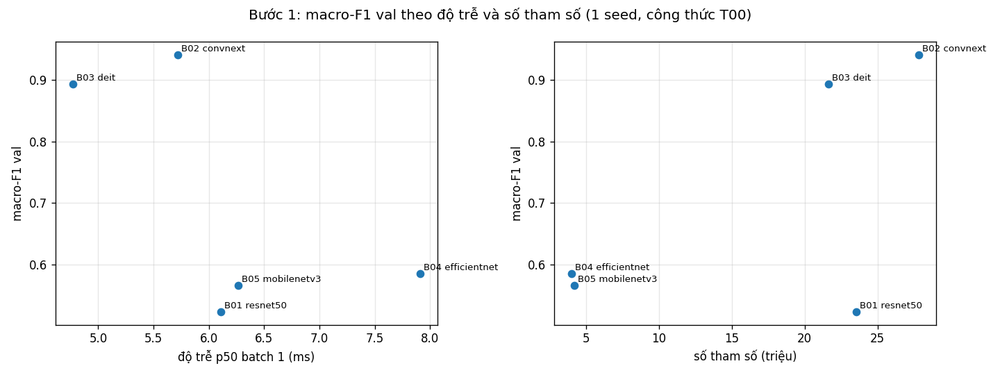

In [12]:
import make_results
make_results.main(str(OUT))
xl = pd.read_excel(OUT / "results.xlsx", sheet_name=None)
for name, df in xl.items():
    print("=====", name, df.shape)
    display(df.head(15))
display(ShowImage(str(OUT / "figures" / "backbones_f1_latency_params.png")))